<a href="https://colab.research.google.com/github/NguyenNguyen1504/GROUP-5-BPFE/blob/main/GROUP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS-A1160 – Beginner's Python for Engineers**

#**Group 5 – Does Stadium Size Determine Home Advantage in the English Premier League?**

---

# **Project Introduction**


Home advantage is one of the most widely discussed phenomena in professional soccer. Teams playing on their own ground tend to win more often than away. But why? One plausible factor is crowd noise and the atmosphere which can be considered to directly correlate with stadium size.

Our group investigates the relationship between Premier League clubs' home stadium capacities and those home win rates, using over 25 seasons of match results(1995-2022). We also examine this relationship during COVID-19 (2020-2021 season) when matches were played without audiences, which allows us to partially isolate crowd effect from other home-ground factors.


#**Group Members & Responsibilities**



| Member | Main Responsibilities |
|--------|----------------------|
| Nguyen Vo Trong Nguyen | Data processing |
| Jedidiah Paul | Data researching |
| Steel James | Presentations script, slides |
| Simanainen Aleksi | Presentation script, slides |
| Nguyen Quang Thai | Written report, conclusions  |

# **I. Load and clean datasets**



### Description of the Datasets

**Base dataset – EPL match results (`results.csv`)**
Source: Kaggle – *Premier League Match Data 1993–2022* (https://www.kaggle.com/datasets/evangower/premier-league-match-data). Licence: CC BY 4.0.

The dataset contains one row per match. The columns used in this analysis are:

| Column | Type | Description |
|--------|------|-------------|
| `Season` | String | Football season in the format `YYYY-YY` (e.g. `2019-20`) |
| `DateTime` | String | ISO 8601 timestamp of the match |
| `HomeTeam` | String | Name of the home team |
| `AwayTeam` | String | Name of the away team |
| `FTHG` | Integer | Full-time home goals |
| `FTAG` | Integer | Full-time away goals |
| `FTR` | String | Full-time result: `H` = Home win, `A` = Away win, `D` = Draw |

The dataset covers seasons 1993-1994  onwards, but 1993-1994 and 1994-1995 seasons had 22 clubs (not 20 like most of the seasons after), making them different. These two seasons are dropped to ensure consistency. All other seasons have complete result data for the columns above, so no further row-level null removal is needed.

**Additional dataset – Home stadium capacities**
Source: Wikipedia and NBC Sports (https://www.nbcsports.com/soccer/news/list-of-premier-league-stadiums-every-clubs-current-and-former-ground-from-the-pl-era).

Stadium capacities are encoded in the notebook as Python dictionaries, distinguishing clubs that moved to a new stadium during the period  that data was collected (e.g. Arsenal : Highbury-> Emirates in 2006-07) from those whose capacity has remained constant. The capacity value for each match row is determined by the home team and the season of that match.

The plausible connection between the 2 sources is that crowd sizes (proxied by the capacities) drive home advantages through crowds' noise and referee/player psychological state. We therefore expect larger stadiums to correlate with higher win rates at home stadium.

### **Setup path and read input**



**Note:** to successfully read the dataset via this path, you have to
 1. Access the [dataset folder](https://drive.google.com/drive/folders/1aZVm3_cJMeG6qmPZ9yarHtqOA5ECEuh4?usp=sharing) on Google Drive.
 2. Create a shortcut of that folder in your own **My Drive** folder on Google Drive.

In [19]:
from google.colab import drive
import os
import pandas as pd
#Mount google drive so the dataset file is accessible
drive.mount('/content/drive')
#Path to the base dataset CSV on google drive
base_dataset_path = '/content/drive/MyDrive/EPL_data/results.csv'

#Load the CSV into a dataframe only if the file exists, print an error other wise
if os.path.exists(base_dataset_path):
    df_results = pd.read_csv(base_dataset_path, encoding="latin1") # Base dataset
    print("Read data successfully.")
    display(df_results.head())

else:
    print("Error: file not found.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Read data successfully.


,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
0,1993-94,1993-08-14T00:00:00Z,Arsenal,Coventry,0,3,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-94,1993-08-14T00:00:00Z,Aston Villa,QPR,4,1,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-94,1993-08-14T00:00:00Z,Chelsea,Blackburn,1,2,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-94,1993-08-14T00:00:00Z,Liverpool,Sheffield Weds,2,0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-94,1993-08-14T00:00:00Z,Man City,Leeds,1,1,D,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Clean data**

We keep only 7 columns relevant to our analysis and remove 1993-1994 and 1994-1995 seasons that had 22 clubs to keep the consistency and avoid skewing win-rate averages.

In [20]:
#select only the columns relevant to the analysis
columns_to_keep = ['Season', 'DateTime', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']
# 93-94 and 94-95 seasons had 22 teams
#Dropping them to keeps the structure consistent across all seasons
rows_to_drop = ['1993-94', '1994-95']
df_results = df_results[columns_to_keep].copy()
df_results = df_results[~df_results['Season'].isin(rows_to_drop)].copy()

### **Create dictionaries saving data of clubs' home stadiums capacities**

**Source: Wikipedia, NBC Sports** (https://www.nbcsports.com/soccer/news/list-of-premier-league-stadiums-every-clubs-current-and-former-ground-from-the-pl-era)

Additional data of home stadium capacities for every Premier League club in our dataset. Clubs that moved to new stadium with larger capacity during the data period are stored in `changes` dictionary with the season they moved as the key; all other clubs with stable stadiums are stored in the `fixed` dictionary.


In [21]:
# Teams with changed stadiums
changes = {
    'Arsenal':       [('2006-07', 60704), ('1993-94', 38419)],
    'Man City':      [('2003-04', 53400), ('1993-94', 35150)],
    'Southampton':   [('2001-02', 32384), ('1993-94', 15200)],
    'Leicester':     [('2002-03', 32261), ('1993-94', 22000)],
    'Middlesbrough': [('1995-96', 34742), ('1993-94', 26667)],
    'West Ham':      [('2016-17', 60000), ('1993-94', 35016)],
    'Tottenham':     [('2019-20', 62850), ('1993-94', 36284)],
    'Bolton':        [('1997-98', 28723), ('1993-94', 22000)],
    'Sunderland':    [('1997-98', 49000), ('1993-94', 22000)]
}

# Teams with unchanged stadiums
fixed = {
    'Man United':       74197,
    'Liverpool':        54074,
    'Newcastle':        52258,
    'Aston Villa':      42785,
    'Chelsea':          40173,
    'Everton':          39414,
    'Sheffield Weds':   39812,
    'Leeds':            37890,
    'Blackburn':        31367,
    'Wolves':           32050,
    'Sheffield United': 32050,
    'Brighton':         31876,
    'Ipswich':          29813,
    'Birmingham':       29409,
    'Stoke':            27902,
    'Norwich':          27359,
    'Charlton':         27111,
    'West Brom':        26850,
    'Wimbledon':        26309,
    'Fulham':           25700,
    'Crystal Palace':   25486,
    'Hull':             25400,
    'Wigan':            25138,
    'Bradford':         25136,
    'Huddersfield':     24500,
    'Reading':          24161,
    'Barnsley':         23009,
    'Watford':          22200,
    'Burnley':          21944,
    'Swansea':          21088,
    'Portsmouth':       20700,
    'QPR':              18360,
    'Brentford':        17250,
    'Blackpool':        16220,
    'Swindon':          15728,
    'Oldham':           13512,
    'Bournemouth':      11307,
    'Derby':            33597,
    'Cardiff':          33280,
    'Coventry':         32609,
    "Nott'm Forest":    30404
}

### **Create a column for home stadium capacity in the big dataset**

The `get_capacity` function retrieves a team's stadium capacity for a specific season. It first checks the `changes` dictionary for teams that relocated; if no match is found, it falls back to the `fixed` dictionary. If the team is missing from both, it logs a warning.

The capacity then merged into the main DataFrame as new column `HomeTeam_StadiumCapacity` using `.apply()` - equivalent to performing a conditional join between match data and stadium data .

In [22]:
def get_capacity(team, season):
#Return the home stadium capacity for 'team' during 'season'
#Handle clubs that changed stadium by checking the 'changes' dictionary first
#Falls back to the 'fixed' dictionary for clubs with unchanged stadiums.]
    if team in changes:
        for from_season, cap in changes[team]:
            if season >= from_season:
                return cap

    if team in fixed:
        return fixed[team]
 #warn if a team is missing from both dictionarises
    print(f"WARNING: No capacity data for team '{team}'")
    return None
#apply the funciton row-by-row to create the  new 'HomeTeam_StadiumCapacity' column
#This merges the stadium data into the base DataFrame
df_results['HomeTeam_StadiumCapacity'] = df_results.apply(lambda row: get_capacity(row['HomeTeam'],row['Season']), axis=1)
df_results = df_results.reset_index(drop=True)

display(df_results.head())

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HomeTeam_StadiumCapacity
0,1995-96,1995-08-19T00:00:00Z,Aston Villa,Man United,3,1,H,42785
1,1995-96,1995-08-19T00:00:00Z,Blackburn,QPR,1,0,H,31367
2,1995-96,1995-08-19T00:00:00Z,Chelsea,Everton,0,0,D,40173
3,1995-96,1995-08-19T00:00:00Z,Liverpool,Sheffield Weds,1,0,H,54074
4,1995-96,1995-08-19T00:00:00Z,Man City,Tottenham,1,1,D,35150


Sort the teams into groups with `Small`, `Medium`, and `Large` home stadium capacity.

In [23]:
# Bin stadium capacities into 3 equal-width groups (S/M/L)
df_results['CapacityGroup'] = pd.cut(
    df_results['HomeTeam_StadiumCapacity'],
    bins = 3,
    labels = ['Small', 'Medium', 'Large']
)
display(df_results.head())

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HomeTeam_StadiumCapacity,CapacityGroup
0,1995-96,1995-08-19T00:00:00Z,Aston Villa,Man United,3,1,H,42785,Medium
1,1995-96,1995-08-19T00:00:00Z,Blackburn,QPR,1,0,H,31367,Small
2,1995-96,1995-08-19T00:00:00Z,Chelsea,Everton,0,0,D,40173,Medium
3,1995-96,1995-08-19T00:00:00Z,Liverpool,Sheffield Weds,1,0,H,54074,Large
4,1995-96,1995-08-19T00:00:00Z,Man City,Tottenham,1,1,D,35150,Medium


### **Assign the matches to the COVID period**

2020-2021 season is `COVID` period. Seasons before `COVID` (2020-2021) are labelled `pre-COVID` and those after  are labelled `post-COVID`. This allows us to isolate the crowd effect: if home advantage is driven by crowd, so expected home win rates will drop uniformly during `COVID` season (2020-2021).

In [24]:
def covid_period(season):
  if season < '2020-21':
    return 'pre-COVID'
  elif season == '2020-21':
    return 'COVID'
  else:
    return 'post-COVID'

df_results['COVID_period'] = df_results['Season'].apply(lambda season: covid_period(season))
display(df_results.head(10))

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HomeTeam_StadiumCapacity,CapacityGroup,COVID_period
0,1995-96,1995-08-19T00:00:00Z,Aston Villa,Man United,3,1,H,42785,Medium,pre-COVID
1,1995-96,1995-08-19T00:00:00Z,Blackburn,QPR,1,0,H,31367,Small,pre-COVID
2,1995-96,1995-08-19T00:00:00Z,Chelsea,Everton,0,0,D,40173,Medium,pre-COVID
3,1995-96,1995-08-19T00:00:00Z,Liverpool,Sheffield Weds,1,0,H,54074,Large,pre-COVID
4,1995-96,1995-08-19T00:00:00Z,Man City,Tottenham,1,1,D,35150,Medium,pre-COVID
5,1995-96,1995-08-19T00:00:00Z,Newcastle,Coventry,3,0,H,52258,Medium,pre-COVID
6,1995-96,1995-08-19T00:00:00Z,Southampton,Nott'm Forest,3,4,A,15200,Small,pre-COVID
7,1995-96,1995-08-19T00:00:00Z,West Ham,Leeds,1,2,A,35016,Medium,pre-COVID
8,1995-96,1995-08-19T00:00:00Z,Wimbledon,Bolton,3,2,H,26309,Small,pre-COVID
9,1995-96,1995-08-20T00:00:00Z,Arsenal,Middlesbrough,1,1,D,38419,Medium,pre-COVID


# **II. Calculate statistics**

### **Calculate Home win rate for each club across seasons**

Group the data by `Season` and `HomeTeam` with a lambda function to compute the home win rate as the proportion of home matches with result `H`.

In [25]:
# Group by season and home team, then compute home win rate and stadium capacity
# HomeWinRate = fraction of home games won (FTR == 'H') out of all home games played
df_hwin_clubs = df_results.groupby(['Season','HomeTeam']).agg(
    HomeWinRate = ('FTR', lambda col: (col == 'H').mean()),
    StadiumCapacity = ('HomeTeam_StadiumCapacity', 'first')
).reset_index()
display(df_hwin_clubs.head())

,Season,HomeTeam,HomeWinRate,StadiumCapacity
0,1995-96,Arsenal,0.526316,38419
1,1995-96,Aston Villa,0.578947,42785
2,1995-96,Blackburn,0.736842,31367
3,1995-96,Bolton,0.263158,22000
4,1995-96,Chelsea,0.368421,40173


### **Calculate Home win rate - Away win rate by capacity group**

Compute aggregate home win rate and away win rate for each capacity group (`Small`, `Medium`, `Large`) across the dataset. This gives us insight of whether larger stadiums correlate with bigger gap between home and away win rates - signal of stronger home advantage

In [26]:
#compute home and away winrate for each stadium capacity group
df_hwin_awin = df_results.groupby(['CapacityGroup']).agg(
    HomeWinRate = ('FTR', lambda col: (col == 'H').mean()),
    AwayWinRate = ('FTR', lambda col: (col == 'A').mean())
).reset_index()
display(df_hwin_awin.head())

/tmp/ipykernel_2542/333417671.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hwin_awin = df_results.groupby(['CapacityGroup']).agg(


,CapacityGroup,HomeWinRate,AwayWinRate
0,Small,0.365619,0.364858
1,Medium,0.468211,0.270436
2,Large,0.644758,0.152091


### **Calculate Home win rate by capacity group across seasons**

Track home win rate over time for each capacity group. Converting the season string to an int starting year allows us to plot a clean x-axis in the line chart. This longitudinal view let us check if advantage of large-stadium clubs is consistent across decades or if it has changed over time

In [27]:
# Group by season and  capacity group to track winrate over time
df_hwin_seasons = df_results.groupby(['Season','CapacityGroup']).agg(
    HomeWinRate = ('FTR', lambda col: (col == 'H').mean())
).reset_index()
# Extract the starting year of each season as an int for a readable x-axis
df_hwin_seasons['YearStart'] = df_hwin_seasons['Season'].str[:4].astype(int)
display(df_hwin_seasons.head())

/tmp/ipykernel_2542/16114773.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hwin_seasons = df_results.groupby(['Season','CapacityGroup']).agg(


,Season,CapacityGroup,HomeWinRate,YearStart
0,1995-96,Small,0.421053,1995
1,1995-96,Medium,0.478070,1995
2,1995-96,Large,0.763158,1995
3,1996-97,Small,0.350877,1996
4,1996-97,Medium,0.438596,1996


### **Calculate Home win rate by capacity group across COVID periods**

Calculate the mean home win rate for each combination of capacity group and COVID period. It shows directly whether the absence of audiences reduced home advantages or not.

In [28]:
# Compute home win rate grouped by both COVID period and capacity group
# This aggregation is the basis for the COVID impact bar chart
df_hwin_covid = df_results.groupby(['COVID_period','CapacityGroup']).agg(
    HomeWinRate = ('FTR', lambda col: (col == 'H').mean())
).reset_index()
display(df_hwin_covid)

/tmp/ipykernel_2542/1035535124.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hwin_covid = df_results.groupby(['COVID_period','CapacityGroup']).agg(


,COVID_period,CapacityGroup,HomeWinRate
0,COVID,Small,0.263158
1,COVID,Medium,0.385965
2,COVID,Large,0.526316
3,post-COVID,Small,0.296000
4,post-COVID,Medium,0.362637
5,post-COVID,Large,0.645161
6,pre-COVID,Small,0.372239
7,pre-COVID,Medium,0.472732
8,pre-COVID,Large,0.652999


# **III. Visualize**

### **Scatter Plot**

Using scatterplot is appropriate because stadium capacity and home win rate are continuous numeric so a bar chart would not be suitable since both axes are continuous; a line chart would imply a time-ordered sequence that does not exist in this pairing. The linear regression line helps quantify the direction and steepness.

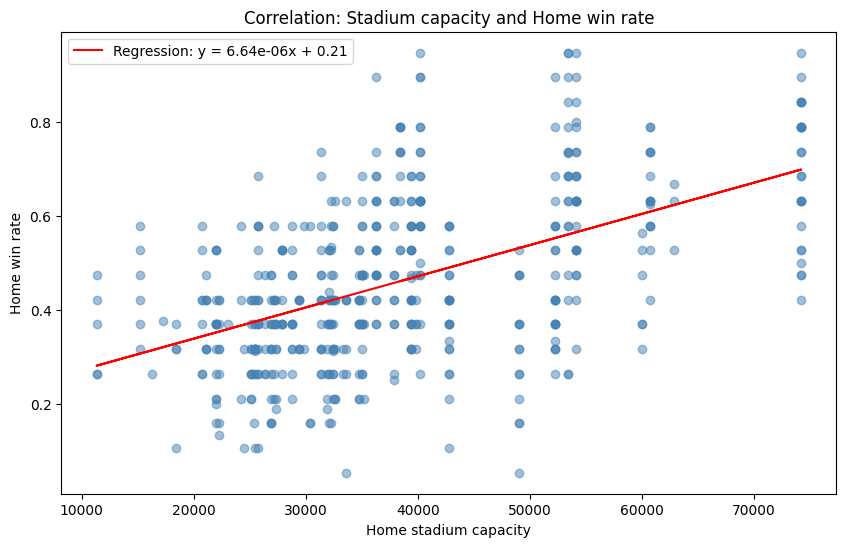

In [29]:
import numpy as np
import matplotlib.pyplot as plt

x = df_hwin_clubs['StadiumCapacity']
y = df_hwin_clubs['HomeWinRate']

# Fit a first-degree  polynomial (linear regression) to x and y
a, b = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('Home stadium capacity')
ax.set_ylabel('Home win rate')
ax.set_title('Correlation: Stadium capacity and Home win rate')

# Each semi-transperent dot represents one club in one season
ax.scatter(x,y, alpha=0.5, color='steelblue')

# Plot the regression line and display its equation in the lengend
ax.plot(x, a * x + b, color='red', label=f'Regression: y = {a:.2e}x + {b:.2f}')
ax.legend()
plt.show()

In [30]:
from scipy.stats import pearsonr
# Pearson's r measures the strength and direction of the linear correlation
# p-value tests whether this correlation is statistically significant
r, p_value = pearsonr(x, y)

print(f"Correlation coefficient (r): {r:.4f}")
print(f"p-value: {p_value:.4e}")

Correlation coefficient (r): 0.5222
p-value: 4.1402e-39


**What does the scatter plot show?**

The scatter plot reveals a clear upward trend: clubs with larger stadiums consistently achieve higher win rates across seasons. The regression line has a positive slop, and the Pearson correlation coefficient $r\approx0.52$ confirms a moderate-to-strong positive linear relationship. The extremely small p-value ($4.14 * 10^{-39}$) means this correlation is highly statistically significant and is very unlikely to be a result of random variation in the data.

### **Grouped Bar Chart**

Here we compare between home and away win rate across 3 categorial groups (`Small`, `Medium`, `Large`). A grouped bar chart is ideal for comparing multiple values side-by-side within categories. A pie chart would not work because we are not showing parts of a whole; a line chart would imply an ordered sequence, but the capacity groups have no natural time ordering. Grouping the bars by capacity group make the home vs. away gap immediately visible.

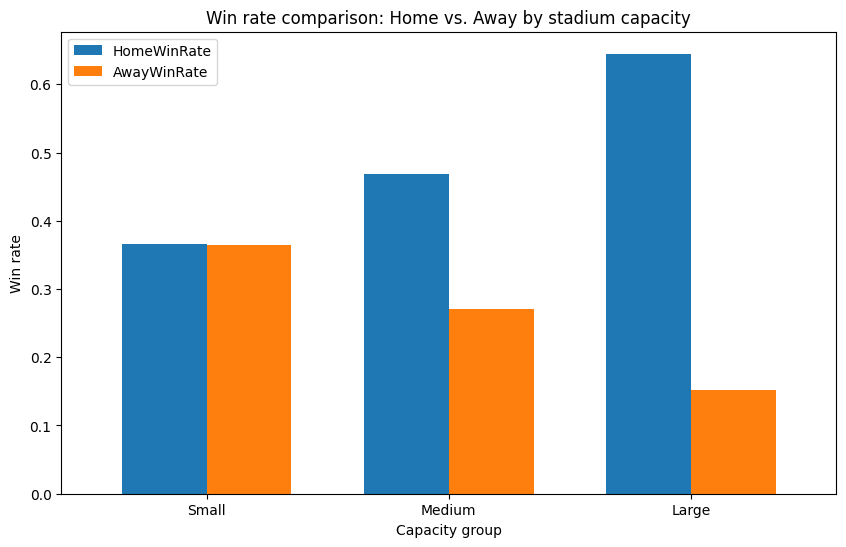

In [31]:
# Pivot the DataFrame so capacity group is the index and win types are columns
df_hwin_awin = df_hwin_awin.set_index('CapacityGroup')

fig, ax = plt.subplots(figsize=(10, 6))

# Plot HomeWinRate and AwayWinRate as grouped bars; legend is auto-generated from column names
df_hwin_awin[['HomeWinRate', 'AwayWinRate']].plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Win rate comparison: Home vs. Away by stadium capacity')
ax.set_xlabel('Capacity group')
ax.set_ylabel('Win rate')
plt.xticks(rotation=0)# keep x-axis labels horizontal for readability
plt.show()

**What does the grouped bar chart show?**

Across all 3 capacity groups, home win rates exceed away win rates, confirming the general existence of home advantage in the EPL. The gap between home and away win rate grows with the stadium size: for small stadiums the difference is nearly 0 while for medium and large stadiums the home win rates arre noticeably higher relative to the away win rates. This supports the hypothesis that crowd size amplifies home advantage.

### **Line Chart**

The x-axis here is time (season starting year), making this time-series data. A line chart is a standard choice for time-series because it highlights trends and continuity between consecutive observations. A bar chart would obscure the year-on-year trends and make it harder to compare the 3 capacity groups across > 25 seasons. Each line represents 1 capacity group, and the legend identifies them.

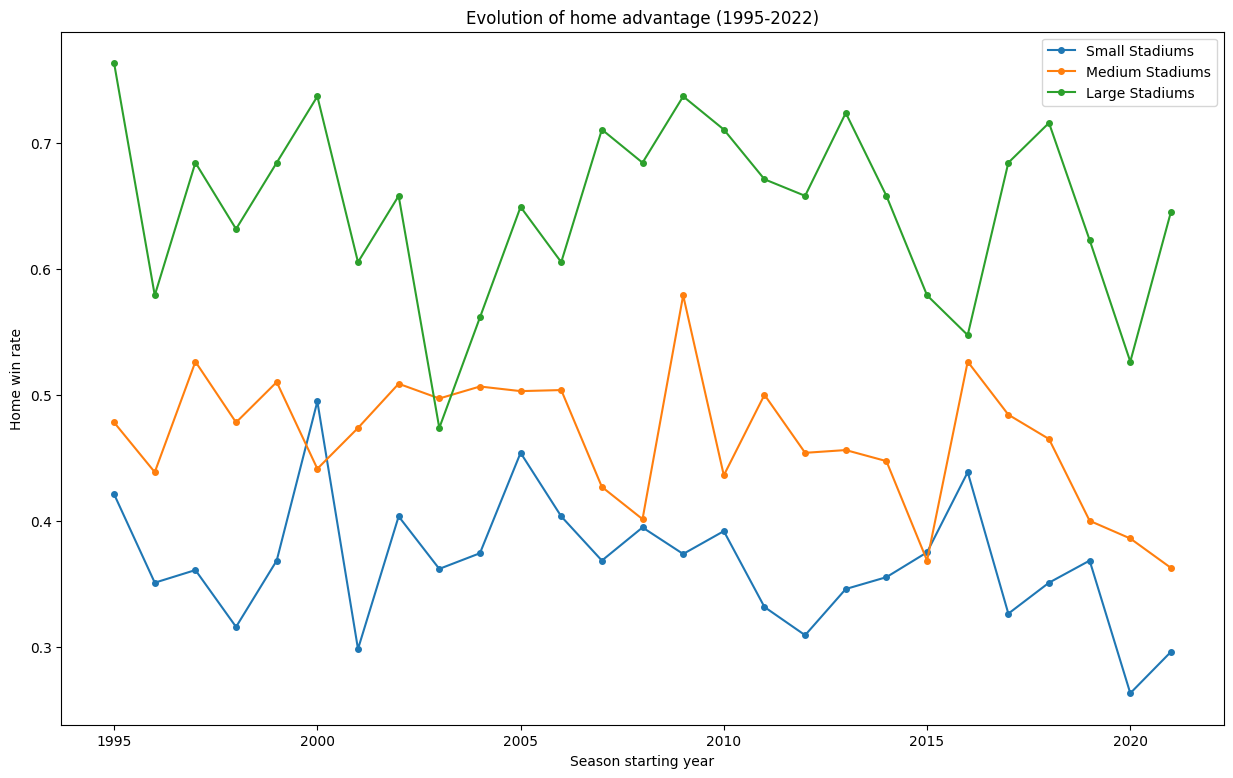

In [32]:
fig, ax = plt.subplots(figsize=(15, 9))
# Plot one line per capacity group to compare their home win rate trends overtime
for group in ['Small', 'Medium', 'Large']:
    data = df_hwin_seasons[df_hwin_seasons['CapacityGroup'] == group]
    ax.plot(data['YearStart'], data['HomeWinRate'], label=f'{group} Stadiums', marker='o', markersize=4)

ax.set_title('Evolution of home advantage (1995-2022)')
ax.set_xlabel('Season starting year')
ax.set_ylabel('Home win rate')
ax.legend()
plt.show()

**What does the line chart show?**

In 1995-2022 period, the `Large` stadium group consistently sits above `Medium` and `Small` groups in terms of home win rate, though all 3 lines fluctuate from season to season. All 3 lines dip noticeably around 2020-2021 (COVID period) before partially recovering. This simultaneous dip in all groups strongly suggests that crowd absence reduced home advantage across the board, not just for large-stadium clubs. The spread between 3 groups also appears to narrow slightly during COVID, consistent with crowds providing a disproportionate boost to larger venues.

### **Bar chart**

The x-axis is a category variable (capacity group) and we compare 3 sub-groups (`pre-COVID`, `COVID`, `post-COVID`) within each category. A grouped bar chart is again the most direct way to visualise categorical comparisions. A line chart would be inappropriate here because the 3 COVID periods are not evenly spaced in time and their ordering is ordinal rather than continuous.

In [33]:
# Pivot to get one column per COVID period, indexed by capacity group
df_pivot = df_hwin_covid.pivot(index='CapacityGroup', columns='COVID_period', values='HomeWinRate')

df_pivot = df_pivot[['pre-COVID', 'COVID', 'post-COVID']]

display(df_pivot)

COVID_period,pre-COVID,COVID,post-COVID
CapacityGroup,,,
Small,0.372239,0.263158,0.296000
Medium,0.472732,0.385965,0.362637
Large,0.652999,0.526316,0.645161


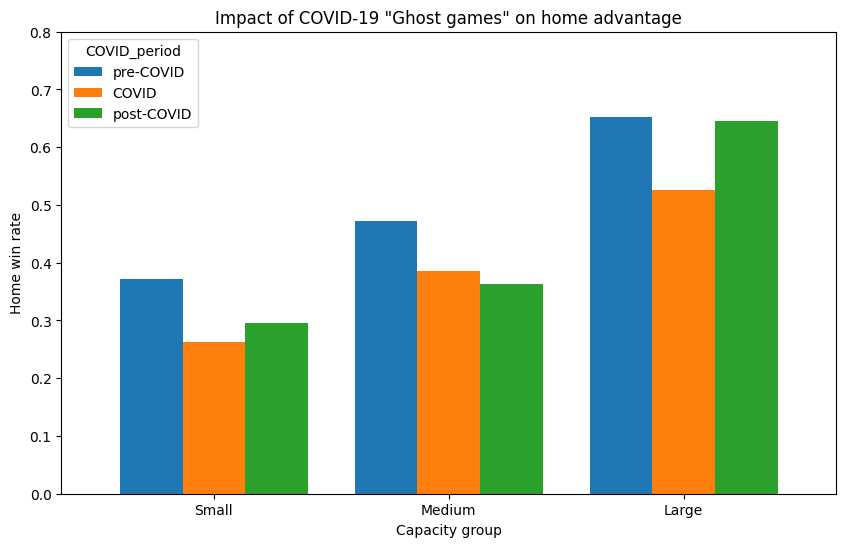

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = df_pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Impact of COVID-19 "Ghost games" on home advantage')
ax.set_xlabel('Capacity group')
ax.set_ylabel('Home win rate')
ax.set_ylim(0, 0.8)
plt.xticks(rotation=0) # keep the labels horizontal

plt.show()

**What does the COVID bar chart show?**


For every capacity group, the home win rate during `COVID` is lower than both the `pre-COVID` and `post-COVID` values. The drop is most pronounced for the `Large` group (from $≈$ 0.65 during `pre-COVID` to $≈$ 0.53 during `COVID`), while the `Small` group shows a smaller drop ( from $≈$ 0.37 to $≈$ 0.26). This pattern suggests that larger stadiums benefit more from audiences presence, and that removing them equalises home advantage partially across stadium sizes. After `COVID`, win rates recover towards `pre-COVID` levels for all groups.

# **IV. Conclusion**

# **Key Findings**

**Finding 1: Larger stadiums correlate with higher home win rates.** The scatter plot and Pearson analysis(r=0.52, p<0.001) confirm a statistically siginificant moderate-to-strong positive correlation between home stadium capacity and home win rate across all seasons from 1995 to 2022. Clubs with  large stadiums (Man utd, Liverpool, Chelsea,...) consistently won more of their home fixtures than clubs with smaller stadiums.

**Finding 2 – Home advantage exists across all stadium sizes, but is amplified by crowd size.**
The grouped bar chart shows that home win rates exceed away win rates for Small, Medium, and Large capacity groups alike. However, the gap between home and away win rate is largest for the Large group, suggesting that bigger, louder crowd provides additional psychological boost — either by encouraging the home team, intimidating the visitors, or subtly influencing referee decisions.

**Finding 3 – Removing the crowd during COVID-19 reduced home advantage, particularly for large stadiums.**
During the 2020–21 COVID season, home win rates dropped for all capacity groups compared to the pre-COVID baseline. The drop was steepest for the Large group (~12 percentage points), while the Small group saw a smaller decline. This finding supports the causal interpretation that audiences — not just home-ground familiarity or travel fatigue — is a meaningful contributor to home advantage.

#**Possible Reasons for the Observed Relationships**

The crowd-noise hypothesis is the most intuitive explanation: larger stadiums generate more noise, which may increase home-player motivation, reduce away-team concentration, and cause referees to unconsciously favour the home side. The COVID data provides partial 'natural experiment' evidence for this, since all other home-ground factors (pitch familiarity, no travel) remained constant while crowds were removed.

It is worth noting that stadium capacity is also correlated with club wealth and squad quality. Richer clubs can afford better players *and* larger stadiums, so part of the higher home win rate for large-stadium clubs may reflect squad quality rather than crowd effect alone. Disentangling these two factors would require controlling for club spending, which is beyond the scope of this project.


# **Reflections on Learning**

**From the data:** We found that the crowd effect on home advantage is real and measurable. The COVID season acts as a natural control group that would be impossible to design deliberately, providing surprisingly clear evidence that fans matter to match outcomes.

**From programming:** This project deepened our understanding of Pandas `groupby` and `agg` for computing grouped statistics, `apply` with lambda functions for row-wise operations, and Matplotlib for producing publication-quality multi-series plots. We also learned how to use SciPy's `pearsonr` function to formally test the significance of an observed correlation, and how to use `pd.cut` to create meaningful categorical bins from a continuous variable.

---
### Sources

1. **Base dataset:** Evangower. (2022). *Premier League Match Data 1993–2022*. Kaggle. https://www.kaggle.com/datasets/evangower/premier-league-match-data. Licence: CC BY 4.0.

2. **Additional data – Stadium capacities:** NBC Sports. (n.d.). *List of Premier League stadiums*. https://www.nbcsports.com/soccer/news/list-of-premier-league-stadiums-every-clubs-current-and-former-ground-from-the-pl-era; Wikipedia contributors, individual stadium articles, https://www.wikipedia.org.

3. **Python libraries used:**
   - McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. pandas. https://pandas.pydata.org
   - Harris, C.R. et al. (2020). *Array programming with NumPy*. NumPy. https://numpy.org
   - Hunter, J.D. (2007). *Matplotlib: A 2D graphics environment*. Matplotlib. https://matplotlib.org
   - Virtanen, P. et al. (2020). *SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python*. SciPy. https://scipy.org
